# Regresión Lineal - Regularización

Las técnicas de **regularización** son útiles para trabajar con conjuntos con **gran cantidad de variables**, las cuales pueden introducir variabilidad en las estimaciones de los parámetros.

### Dataset: NBA
**Objetivo**: predecir el salario de un jugador de la NBA de la temporada 2021 en base a sus estadísticas de juego durante la temporada

Las variables del set son:

| Variable     | Descripción                           |
|---------------|----------------------------------------|
| player        | Nombre                                 |
| salary        | Salario                                |
| position      | Posición en el campo de juego          |
| age           | Edad                                   |
| team_id       | Nombre del equipo                      |
| g             | Cantidad de partidos                   |
| gs            | Partidos como titular                  |
| mp_per_g      | Minutos por partido                    |
| fg_per_g      | Tiros de campo por partido (dobles y triples) |
| fga_per_g     | Intentos de tiro de campo              |
| fg_pct        | Porcentaje de tiros convertidos        |
| fg3_per_g     | Triples por partido                    |
| fg3a_per_g    | Intentos de triples por partido        |
| fg3_pct       | % de triples convertidos               |
| fg2_per_g     | Dobles por partido                     |
| fg2a_per_g    | Intentos de dobles por partido         |
| fg2_pct       | % de dobles convertidos                |
| efg_pct       | Efectividad de tiros de campo          |
| ft_per_g      | Tiros libres por partido               |
| fta_per_g     | Intentos de tiro libre por partido     |
| ft_pct        | % de tiros libres convertidos          |
| orb_per_g     | Rebotes ofensivos por partido          |
| drb_per_g     | Rebotes defensivos por partido         |
| trb_per_g     | Rebotes totales por partido            |
| ast_per_g     | Asistencias por partido                |
| stl_per_g     | Robos por partido                      |
| blk_per_g     | Bloqueos por partido                   |
| tov_per_g     | Pérdidas por partido                   |
| pf_per_g      | Faltas por partido                     |
| pts_per_g     | Puntos por partido                     |


In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [450]:
# Cargar el dataset
df = pd.read_csv("./datasets/nba_salarios_2021.csv")

## Analisis exploratorio de datos (EDA)

A continuación, se realiza un analisis basico para entender mejor las relaciones entre las variables.

In [451]:
df.head()

,player,salary,position,age,team_id,g,gs,mp_per_g,fg_per_g,fga_per_g,...,ft_pct,orb_per_g,drb_per_g,trb_per_g,ast_per_g,stl_per_g,blk_per_g,tov_per_g,pf_per_g,pts_per_g
0,Stephen Curry,43006362.0,PG,31,GSW,5,5,27.8,6.6,16.4,...,1.000,0.8,4.4,5.2,6.6,1.0,0.4,3.2,2.2,20.8
1,Russell Westbrook,41358814.0,PG,31,HOU,57,57,35.9,10.6,22.5,...,0.763,1.8,6.2,7.9,7.0,1.6,0.4,4.5,3.5,27.2
2,Chris Paul,41358814.0,PG,34,OKC,70,70,31.5,6.2,12.7,...,0.907,0.4,4.6,5.0,6.7,1.6,0.2,2.3,2.3,17.6
3,James Harden,40824000.0,SG,30,HOU,68,68,36.5,9.9,22.3,...,0.865,1.0,5.5,6.6,7.5,1.8,0.9,4.5,3.3,34.3
4,LeBron James,39219565.0,PG,35,LAL,67,67,34.6,9.6,19.4,...,0.693,1.0,6.9,7.8,10.2,1.2,0.5,3.9,1.8,25.3


In [452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   player      403 non-null    object 
 1   salary      401 non-null    float64
 2   position    403 non-null    object 
 3   age         403 non-null    int64  
 4   team_id     403 non-null    object 
 5   g           403 non-null    int64  
 6   gs          403 non-null    int64  
 7   mp_per_g    403 non-null    float64
 8   fg_per_g    403 non-null    float64
 9   fga_per_g   403 non-null    float64
 10  fg_pct      403 non-null    float64
 11  fg3_per_g   403 non-null    float64
 12  fg3a_per_g  403 non-null    float64
 13  fg3_pct     403 non-null    float64
 14  fg2_per_g   403 non-null    float64
 15  fg2a_per_g  403 non-null    float64
 16  fg2_pct     403 non-null    float64
 17  efg_pct     403 non-null    float64
 18  ft_per_g    403 non-null    float64
 19  fta_per_g   403 non-null    f

In [453]:
df.describe()

,salary,age,g,gs,mp_per_g,fg_per_g,fga_per_g,fg_pct,fg3_per_g,fg3a_per_g,...,ft_pct,orb_per_g,drb_per_g,trb_per_g,ast_per_g,stl_per_g,blk_per_g,tov_per_g,pf_per_g,pts_per_g
count,4.010000e+02,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,...,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000
mean,8.863481e+06,25.531017,48.982630,25.225806,22.245409,3.758561,8.175434,0.458742,1.103970,3.111663,...,0.746797,0.947891,3.212655,4.158561,2.233499,0.707940,0.460050,1.291563,1.936228,10.247643
std,9.400429e+06,4.024293,19.432168,25.009573,8.327951,2.253597,4.745322,0.083943,0.885839,2.293976,...,0.144606,0.779248,1.878687,2.504304,1.866394,0.396736,0.433391,0.834653,0.741202,6.357873
min,3.400000e+05,19.000000,2.000000,0.000000,3.000000,0.000000,0.300000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000
25%,2.090040e+06,22.000000,36.500000,2.000000,16.000000,2.100000,4.550000,0.414000,0.400000,1.400000,...,0.688500,0.400000,1.800000,2.300000,1.000000,0.400000,0.200000,0.700000,1.500000,5.500000
50%,4.938272e+06,25.000000,56.000000,16.000000,22.900000,3.300000,7.100000,0.446000,1.000000,2.800000,...,0.776000,0.700000,2.900000,3.700000,1.600000,0.700000,0.300000,1.100000,1.900000,9.000000
75%,1.213834e+07,28.000000,64.000000,51.000000,29.250000,4.950000,11.300000,0.489000,1.600000,4.400000,...,0.833000,1.200000,4.000000,5.200000,3.000000,0.900000,0.600000,1.600000,2.400000,13.800000
max,4.300636e+07,39.000000,74.000000,73.000000,37.500000,10.900000,22.900000,0.742000,4.400000,12.400000,...,1.000000,4.400000,11.400000,15.200000,10.200000,2.100000,2.900000,4.800000,4.900000,34.300000


In [454]:
print("Cantidad de datos duplicados:", df.duplicated().sum())
print("Cantidad de nulos:\n", df.isnull().sum()[df.isnull().sum() > 0])

Cantidad de datos duplicados: 4
Cantidad de nulos:
 salary    2
dtype: int64


### Visualización de datos númericos

In [455]:
numerical_features = df.select_dtypes(include="number").columns.to_list()
categorical_features = df.select_dtypes(include="object").columns.to_list()

print("Características numéricas:", numerical_features)
print("Características categóricas:", categorical_features)

Características numéricas: ['salary', 'age', 'g', 'gs', 'mp_per_g', 'fg_per_g', 'fga_per_g', 'fg_pct', 'fg3_per_g', 'fg3a_per_g', 'fg3_pct', 'fg2_per_g', 'fg2a_per_g', 'fg2_pct', 'efg_pct', 'ft_per_g', 'fta_per_g', 'ft_pct', 'orb_per_g', 'drb_per_g', 'trb_per_g', 'ast_per_g', 'stl_per_g', 'blk_per_g', 'tov_per_g', 'pf_per_g', 'pts_per_g']
Características categóricas: ['player', 'position', 'team_id']


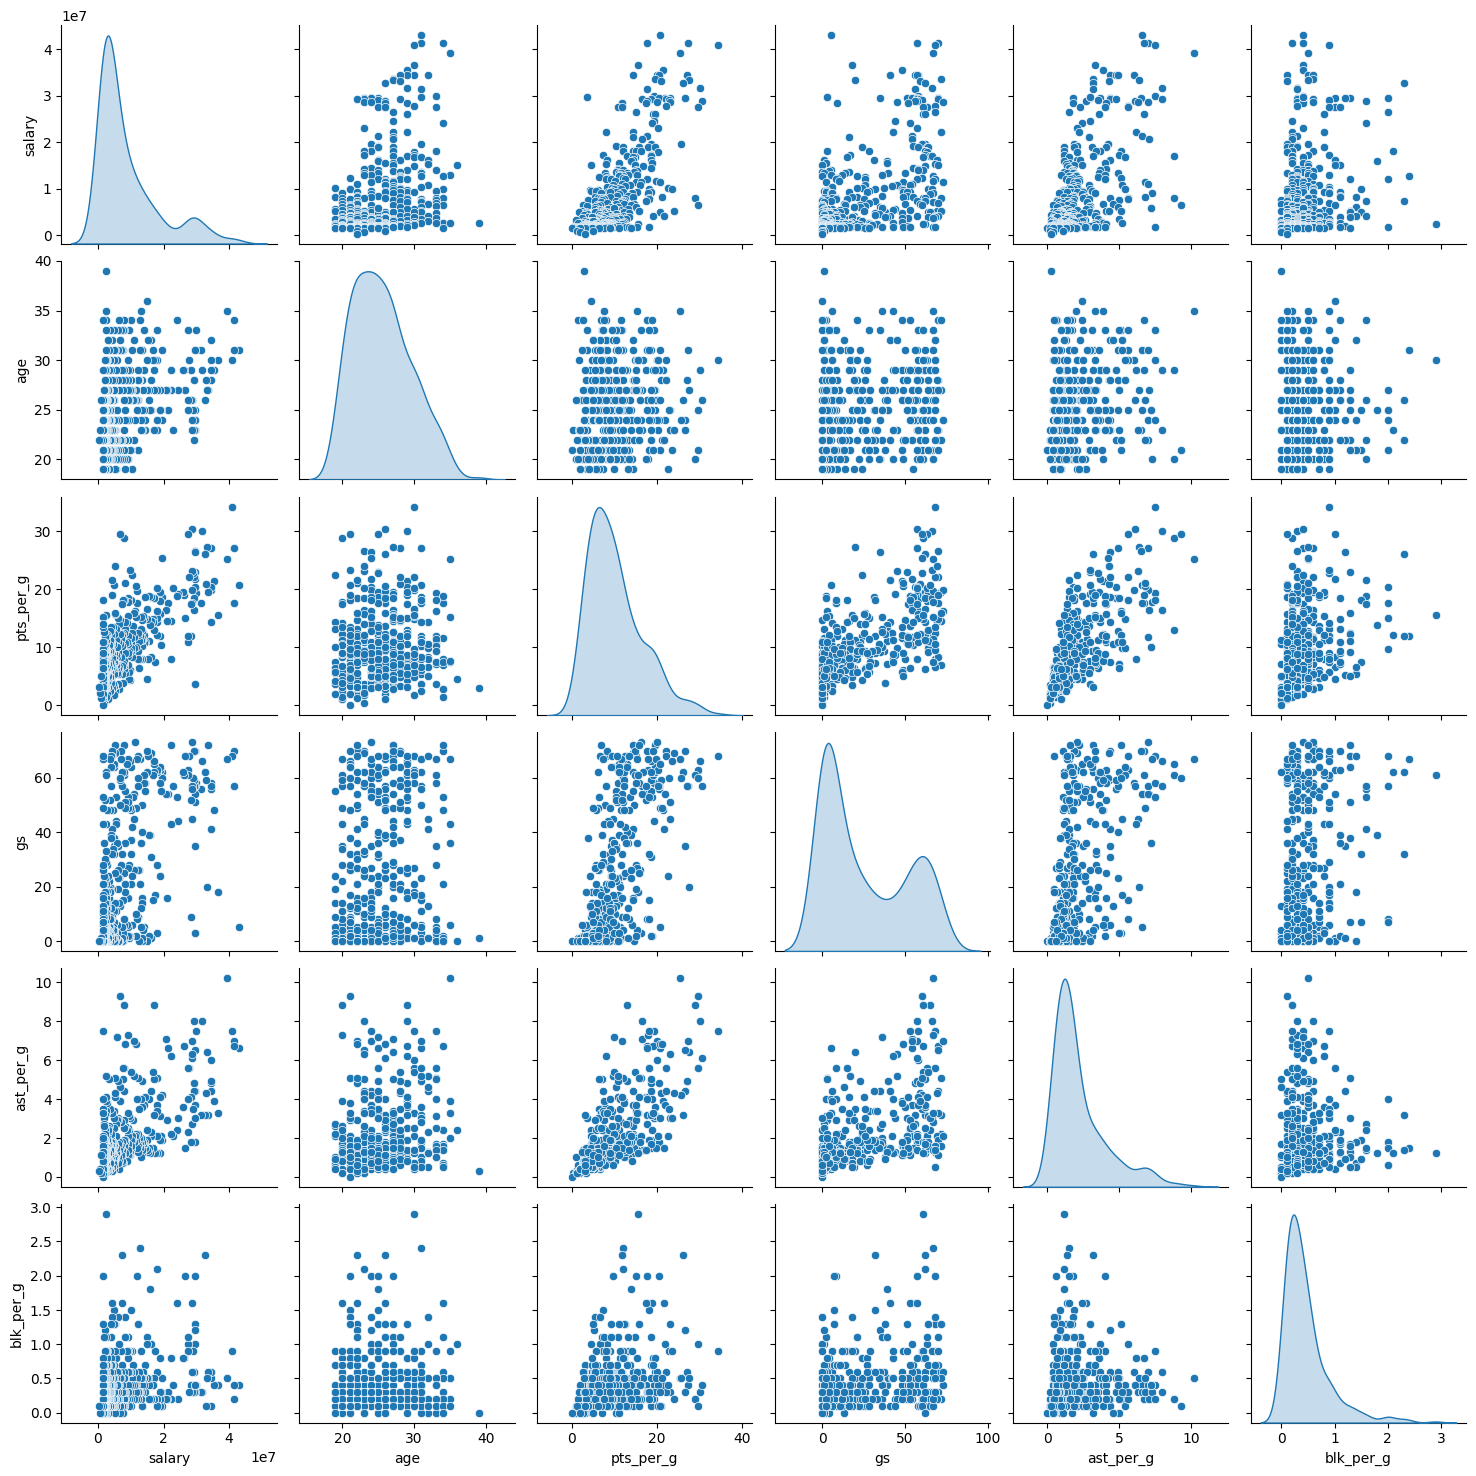

In [456]:
sns.pairplot(data=df[['salary','age','pts_per_g','gs','ast_per_g','blk_per_g']], diag_kind="kde")
plt.show()

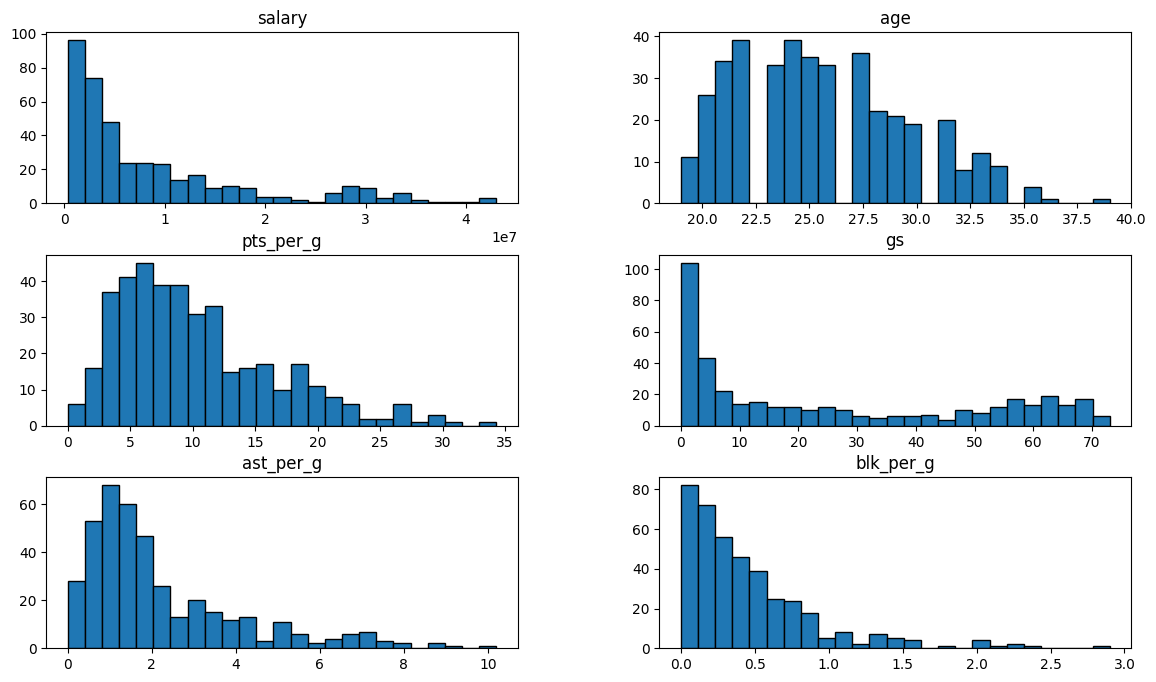

In [457]:
# Graficamos los histogramas de las características y el target
df[['salary','age','pts_per_g','gs','ast_per_g','blk_per_g']].hist(bins=25, figsize=(14, 8), edgecolor='black', grid=False)
plt.show()

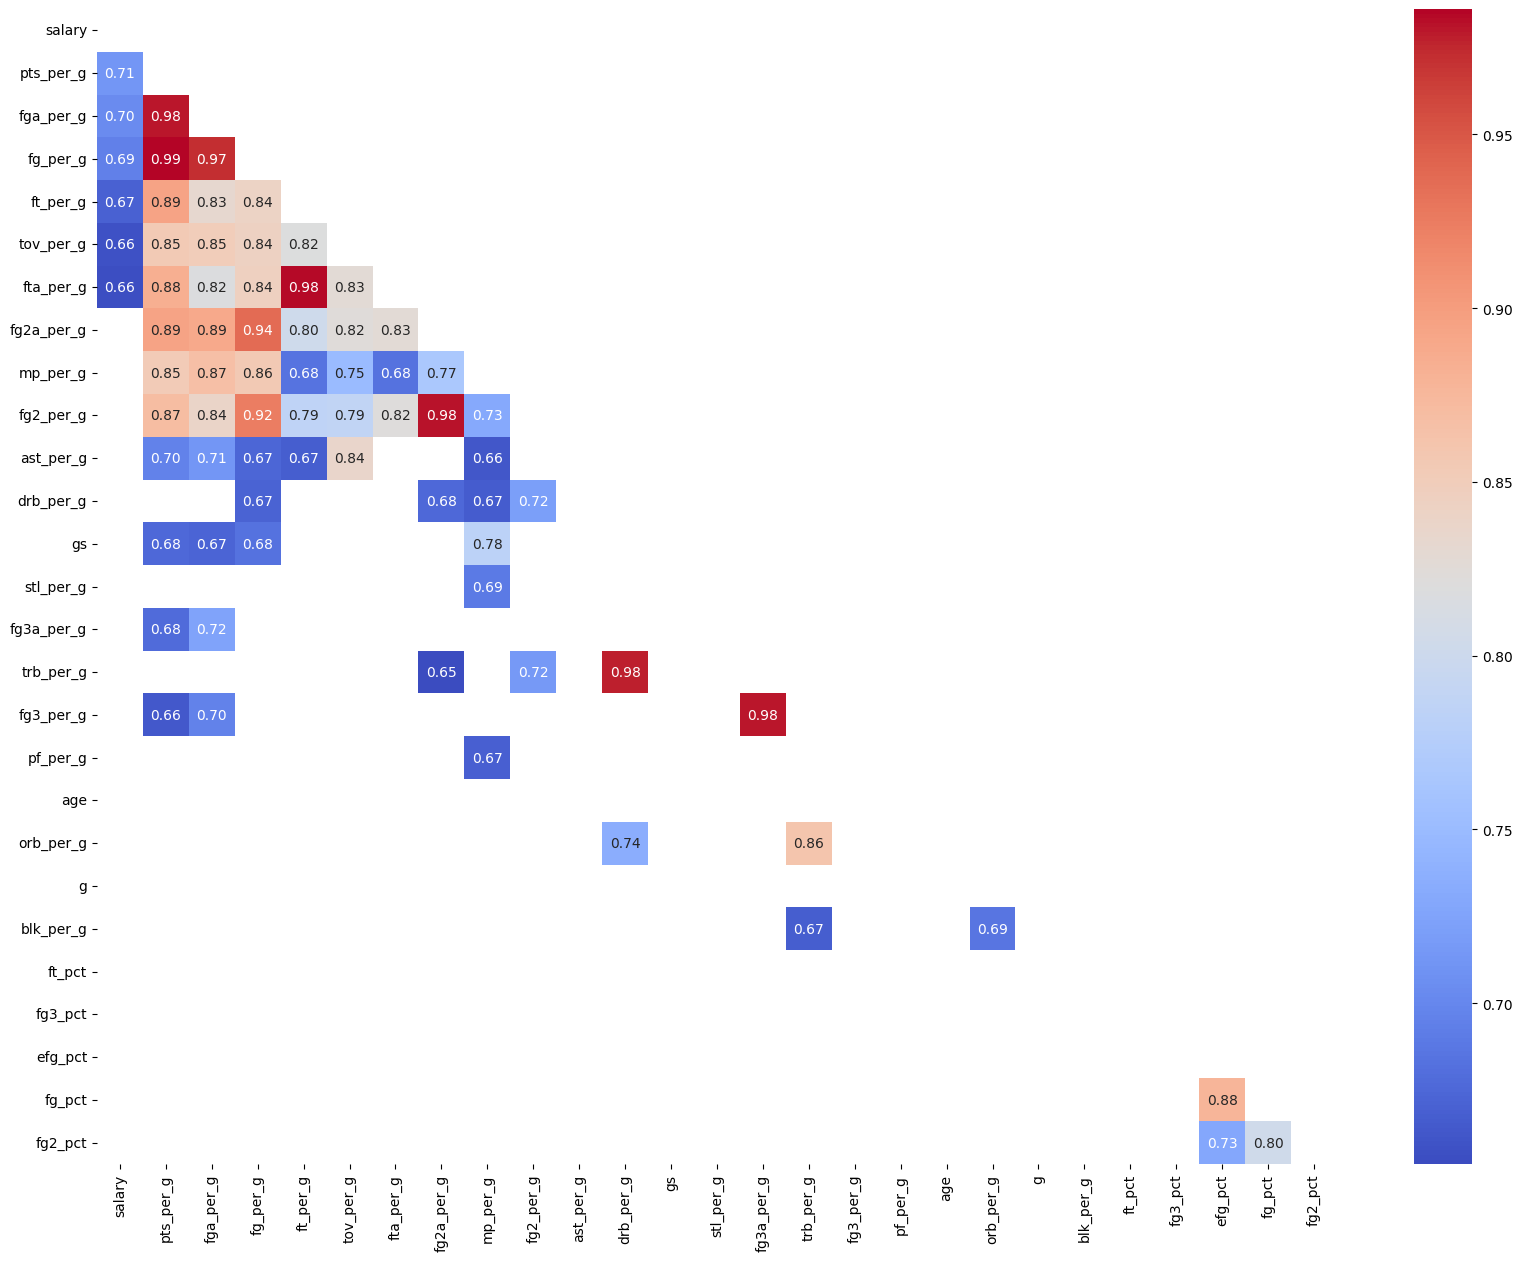

In [458]:
# Graficamos la correlación cruzada
umbral = 0.65

corr = (df[numerical_features].corr(method = 'pearson')
    .sort_values(by = 'salary', axis = 0, ascending = False)
    .sort_values(by = 'salary', axis = 1, ascending = False))

#mask = np.triu(np.ones_like(corr, dtype=np.bool))

mask_threshold = corr.abs() < umbral
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
mask = mask_upper | mask_threshold

plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=True, fmt=".2f", cbar=True, cmap="coolwarm", mask=mask)
plt.show()

### Visualización de datos categoricas

In [459]:
df.describe(include="object")

,player,position,team_id
count,403,403,403
unique,399,12,31
top,Patrick Patterson,SG,TOT
freq,2,92,37


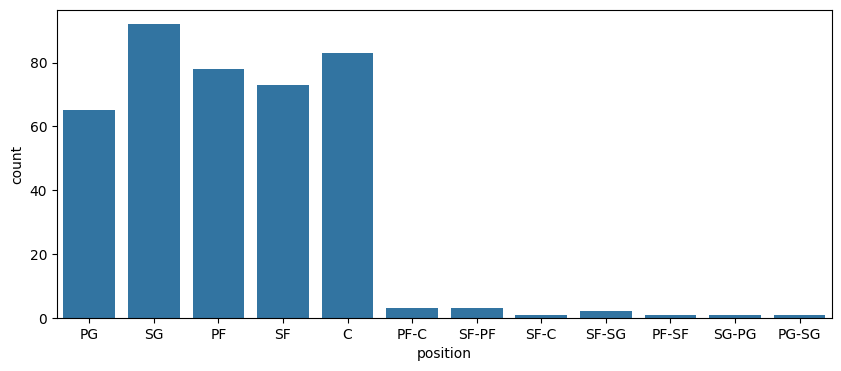

In [460]:
plt.figure(figsize=(10, 4))
sns.countplot(x='position', data=df)
plt.show()

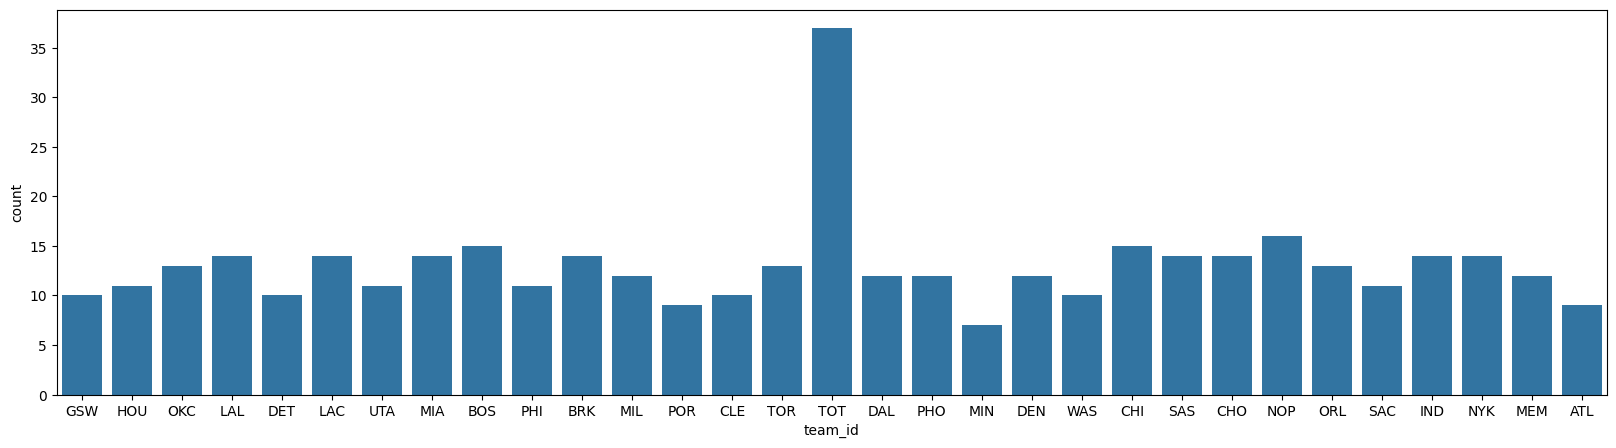

In [461]:
plt.figure(figsize=(20, 5))
sns.countplot(x='team_id', data=df)
plt.show()

In [462]:
df.player.value_counts()

player
Patrick Patterson    2
Elfrid Payton        2
Wayne Ellington      2
Nicolas Batum        2
Grant Williams       1
                    ..
Montrezl Harrell     1
Derrick Favors       1
Jae Crowder          1
Derrick Jones Jr.    1
Maxi Kleber          1
Name: count, Length: 399, dtype: int64

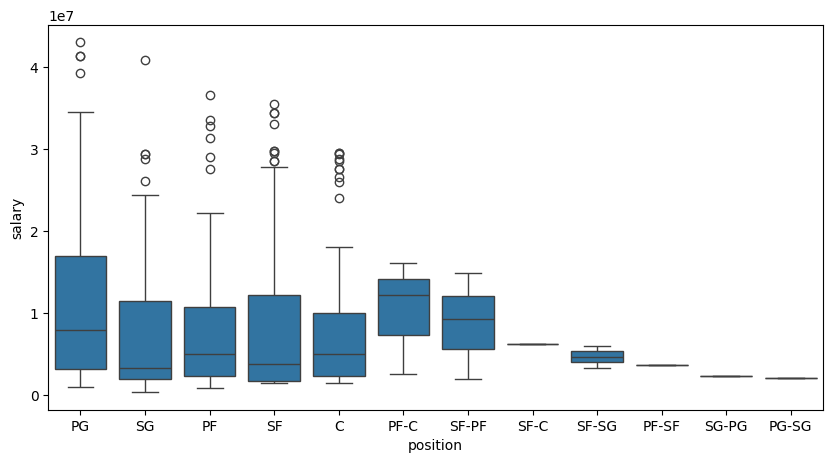

In [463]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='position', y='salary')
plt.show()

<Axes: xlabel='pts_per_g', ylabel='salary'>

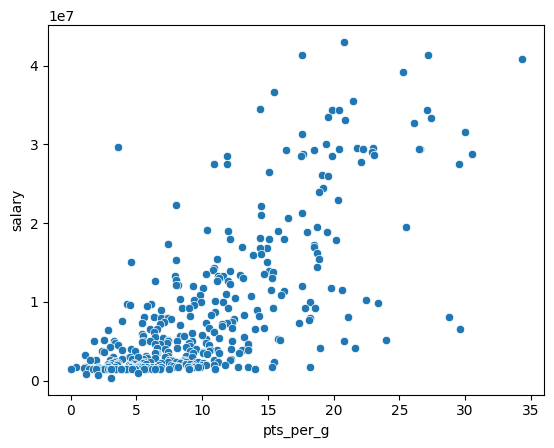

In [480]:
sns.scatterplot(data=df, x="pts_per_g", y="salary")

## Tratamiento de outliers y faltantes

In [464]:
# Eliminamos duplicados y las filas donde el target es nulo
df = df.drop_duplicates()
df = df.dropna()

In [465]:
# Se eliminan posiciones con pocas frecuencias
position_classes = ['PG', 'SG', 'PF', 'SF', 'C']
df = df[df["position"].isin(position_classes)]

In [466]:
# Se elimina el player ya que funciona como id, y el team_id por la alta cardinalidad
df = df.drop(columns=["player", "team_id"], axis=1)

In [467]:
# Se transforma el target para suavizar los outliers
df["salary_log"] = np.log1p(df["salary"])

## Split dataset

In [468]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["salary", "salary_log"])
y = df["salary_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((269, 27), (116, 27), (269,), (116,))

## Codificación

Se codifica la unica variable categorica con OneHotEncoder por tener poca cardinalidad

In [469]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(categories=[position_classes], drop='first', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[["position"]])

X_test_ohe = ohe.transform(X_test[["position"]])

ohe.get_feature_names_out(["position"])

array(['position_SG', 'position_PF', 'position_SF', 'position_C'],
      dtype=object)

Escalamos solo las variables númericas. No es recomendable escalar las codificadas con OneHotEncoder

In [470]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_features = X_train.select_dtypes(include="number").columns.to_list()

X_train_scaled = scaler.fit_transform(X_train[numerical_features])

X_test_scaled = scaler.transform(X_test[numerical_features])

Unimos los datos para entrenar

In [471]:
X_train_final = np.concatenate([X_train_scaled, X_train_ohe], axis=1)
X_test_final  = np.concatenate([X_test_scaled, X_test_ohe], axis=1)

X_train_final.shape, X_test_final.shape

((269, 30), (116, 30))

## Entrenamiento

In [472]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Validación del modelo

In [473]:
from sklearn.metrics import (r2_score, 
                             mean_absolute_error, 
                             mean_squared_error, 
                             root_mean_squared_error, 
                             mean_absolute_percentage_error)

In [474]:
def print_metrics(y_train, y_pred, model_name):
    r2 = r2_score(y_train, y_pred)
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = root_mean_squared_error(y_train, y_pred)
    mape = mean_absolute_percentage_error(y_train, y_pred)

    print("***** Metricas para el modelo", model_name, "*****")
    print("R2:", round(r2, 3))
    print("Error absoluto medio (MAE):", round(mae, 3))
    print("Error cuadrático medio (MSE):", round(mse, 3))
    print("Raíz de error cuadrático medio (RMSE):", round(rmse, 3))
    print(f"Error absoluto porcentual medio (MAPE): {mape*100:.2f}%")
    print("")

#### Entrenamiento

In [476]:
y_pred = linear_model.predict(X_train_final)

print_metrics(np.expm1(y_train), np.expm1(y_pred), "Linear")

***** Metricas para el modelo Linear *****
R2: 0.656
Error absoluto medio (MAE): 3386022.176
Error cuadrático medio (MSE): 27441658985393.07
Raíz de error cuadrático medio (RMSE): 5238478.69
Error absoluto porcentual medio (MAPE): 53.19%



#### Evaluación

In [477]:
y_pred_linear = linear_model.predict(X_test_final)

# print_metrics(y_test, y_pred_linear, "Linear")
print_metrics(np.expm1(y_test), np.expm1(y_pred_linear), "Linear")

***** Metricas para el modelo Linear *****
R2: 0.526
Error absoluto medio (MAE): 4331357.377
Error cuadrático medio (MSE): 51636221962002.07
Raíz de error cuadrático medio (RMSE): 7185834.813
Error absoluto porcentual medio (MAPE): 49.19%



Vemos que las metricas son bastantes malas por lo cual se van a usar otro modelos para ver si mejora

---
## Regularización

In [358]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

In [359]:
lasso = LassoCV(cv=10, max_iter=10000, n_jobs=-1)
lasso.fit(X_train_final, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,10000
,tol,0.0001
,copy_X,True
,cv,10
,verbose,False
,n_jobs,-1


In [360]:
print(f"El lambda final obtenido mediante CV es: {lasso.alpha_}")
print(f"Cantidad de features: {(lasso.coef_ != 0).sum()}")

El lambda final obtenido mediante CV es: 0.04197494270090557
Cantidad de features: 7


In [361]:
# Ajustamos el modelo para 100 valores distintos de lambda
n_alphas = 100
alphas = np.logspace(1, 8, n_alphas)

ridge = RidgeCV(alphas=alphas, cv=10)
ridge.fit(X_train_final, y_train)

,alphas,array([1.0000...00000000e+08])
,fit_intercept,True
,scoring,None
,cv,10
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [362]:
print(f"El lambda final obtenido mediante CV es: {ridge.alpha_}")

El lambda final obtenido mediante CV es: 97.70099572992251


In [363]:
enet = ElasticNetCV(cv=10, max_iter=5000)
enet.fit(X_train_final, y_train)

,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,5000
,tol,0.0001
,cv,10
,copy_X,True
,verbose,0


In [364]:
print(f"El lambda final obtenido mediante CV es: {enet.alpha_}" )

El lambda final obtenido mediante CV es: 0.08394988540181111


Evaluamos los modelos

In [365]:
y_pred_lasso = lasso.predict(X_test_final)
y_pred_ridge = ridge.predict(X_test_final)
y_pred_enet = enet.predict(X_test_final)

#print_metrics(y_test, y_pred_lasso, "Lasso")
print_metrics(np.expm1(y_test), np.expm1(y_pred_lasso), "Lasso")
#print_metrics(y_test, y_pred_ridge, "Ridge")
print_metrics(np.expm1(y_test), np.expm1(y_pred_ridge), "Ridge")
#print_metrics(y_test, y_pred_enet, "ElasticNet")
print_metrics(np.expm1(y_test), np.expm1(y_pred_enet), "ElasticNet")

print_metrics(np.expm1(y_test), np.expm1(y_pred_linear), "Linear")

***** Metricas para el modelo Lasso *****
R2: 0.548
Error absoluto medio (MAE): 4468927.498
Error cuadrático medio (MSE): 49226315612935.484
Raíz de error cuadrático medio (RMSE): 7016146.778
Error absoluto porcentual medio (MAPE): 52.28%

***** Metricas para el modelo Ridge *****
R2: 0.539
Error absoluto medio (MAE): 4414387.129
Error cuadrático medio (MSE): 50145690451017.18
Raíz de error cuadrático medio (RMSE): 7081362.189
Error absoluto porcentual medio (MAPE): 51.03%

***** Metricas para el modelo ElasticNet *****
R2: 0.538
Error absoluto medio (MAE): 4506200.465
Error cuadrático medio (MSE): 50287469503422.516
Raíz de error cuadrático medio (RMSE): 7091365.842
Error absoluto porcentual medio (MAPE): 52.51%

***** Metricas para el modelo Linear *****
R2: 0.526
Error absoluto medio (MAE): 4331357.377
Error cuadrático medio (MSE): 51636221962002.07
Raíz de error cuadrático medio (RMSE): 7185834.813
Error absoluto porcentual medio (MAPE): 49.19%



---

## Búsqueda de hiperparametros

In [368]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import ElasticNet

In [387]:
#Definimos la grilla
parametros = {
    'alpha':[0.001,0.01,0.1,1,5,20],
    'l1_ratio':[0,0.25,0.5,0.75,1],
}

enet = ElasticNet()

grid_search = GridSearchCV(estimator=enet, param_grid=parametros, cv=20, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_final, y_train)

print(f"Mejor combinación de parámetros {grid_search.best_params_}")

/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.614e+01, tolerance: 2.447e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.431e+01, tolerance: 2.560e-02
Linear regression models with a zero l1 penalization strength are more efficiently 

Mejor combinación de parámetros {'alpha': 0.1, 'l1_ratio': 0.25}


/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.768e+01, tolerance: 2.462e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.687e+01, tolerance: 2.471e-02
Linear regression models with a zero l1 penalization strength are more efficiently 

In [397]:
enet = ElasticNet()

random_search = RandomizedSearchCV(estimator=enet, param_distributions=parametros,scoring="neg_mean_squared_error", n_jobs=-1, cv=20)

random_search.fit(X_train_final, y_train)

print(f"Best Score: {random_search.best_score_}")
print(f"Mejor combinación de parámetros {random_search.best_params_}")

Best Score: -0.42875494050265495
Mejor combinación de parámetros {'l1_ratio': 0.25, 'alpha': 0.01}


/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.017e+02, tolerance: 2.560e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/comejia/projects/machine-learning-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.846e+01, tolerance: 2.447e-02
Linear regression models with a zero l1 penalization strength are more efficiently 

In [398]:
enet_grid_best = ElasticNet(**grid_search.best_params_)

enet_grid_best.fit(X_train_final, y_train)

enet_random_best = ElasticNet(**random_search.best_params_)

enet_random_best.fit(X_train_final, y_train)

,alpha,0.01
,l1_ratio,0.25
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [ ]:
y_pred_grid = enet_grid_best.predict(X_test_final)
y_pred_random = enet_random_best.predict(X_test_final)

print_metrics(np.expm1(y_test), np.expm1(y_pred_grid), "Best Grid")
print_metrics(np.expm1(y_test), np.expm1(y_pred_random), "Best Random")

***** Metricas para el modelo Best Grid *****
R2: 0.553
Error absoluto medio (MAE): 4422340.104
Error cuadrático medio (MSE): 48655260261325.99
Raíz de error cuadrático medio (RMSE): 6975332.269
Error absoluto porcentual medio (MAPE): 51.81%

***** Metricas para el modelo Best Random *****
R2: 0.58
Error absoluto medio (MAE): 4241486.083
Error cuadrático medio (MSE): 45662949467242.92
Raíz de error cuadrático medio (RMSE): 6757436.605
Error absoluto porcentual medio (MAPE): 49.53%



Con la busqueda de hiperparametros vemos una leve mejora.

## (Bonus) Uso de pipeline para entrenamiento

In [533]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(categories=[position_classes], drop='first'), ["position"]), 
        ('num', StandardScaler(), numerical_features)   
    ]
)

regressor = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-4, 1, 50), cv=5, scoring="neg_mean_squared_error"),
    func=np.log1p,
    inverse_func=np.expm1
)

# Pipeline: preprocesamiento + modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', regressor)
])

pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [534]:
X_train, X_test, y_train, y_test = train_test_split(X, df["salary"], test_size=0.3, random_state=42)

In [535]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [536]:
y_train_pred = pipeline.predict(X_train)

print_metrics(y_train, y_train_pred, "Linear")

***** Metricas para el modelo Linear *****
R2: 0.634
Error absoluto medio (MAE): 3481290.693
Error cuadrático medio (MSE): 29189577536190.875
Raíz de error cuadrático medio (RMSE): 5402737.967
Error absoluto porcentual medio (MAPE): 55.04%



In [537]:
y_pred = pipeline.predict(X_test)

print_metrics(y_test, y_pred, "Linear")

***** Metricas para el modelo Linear *****
R2: 0.579
Error absoluto medio (MAE): 4262506.056
Error cuadrático medio (MSE): 45813039805880.734
Raíz de error cuadrático medio (RMSE): 6768533.062
Error absoluto porcentual medio (MAPE): 49.91%

